# Baseline: Logistic Regression on metadata

In [25]:
# %% Cell 1: Imports & Configuration
import os
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, linregress
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (balanced_accuracy_score, f1_score, classification_report, 
                             confusion_matrix, matthews_corrcoef, brier_score_loss, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import joblib
import shap

warnings.filterwarnings("ignore")

# --- Project Root Setup ---
def find_project_root(name='Bambino', start=None):
    if start is None:
        start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name:
            return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir:
            return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
if PROJECT_ROOT:
    sys.path.append(PROJECT_ROOT)
    print(f"✅ Added project root: {PROJECT_ROOT}")
else:
    print("❌ Project root not found.")
    sys.exit(1)

from config import settings
from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset

# --- Paths ---
DATASET_TYPE = "normalized"  # 'normalized' or 'augmented_normalized'
TRAIN_PATH = settings.get_dataset_path(DATASET_TYPE, settings.training_filename)
VAL_PATH = settings.get_dataset_path(DATASET_TYPE, settings.validation_filename)
TEST_PATH = settings.get_dataset_path(DATASET_TYPE, settings.test_filename)

OUT_DIR = Path("./baseline_results") if DATASET_TYPE == "normalized" else Path("./baseline_results_augmented")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# %% Cell 2: Feature Extraction Engine
def compute_descriptors(signal, prefix):
    """
    Computes statistical, temporal, and complexity metrics for a single 1D signal.
    """
    if len(signal) == 0:
        return {}
    
    # 1. Statistical
    mean_val = np.mean(signal)
    std_val = np.std(signal)
    min_val = np.min(signal)
    max_val = np.max(signal)
    p25 = np.percentile(signal, 25)
    p50 = np.percentile(signal, 50)
    p75 = np.percentile(signal, 75)
    
    # Handle constant signals for skew/kurtosis
    if std_val < 1e-6:
        skew_val = 0.0
        kurt_val = 0.0
    else:
        skew_val = skew(signal)
        kurt_val = kurtosis(signal)

    # 2. Temporal / Dynamics
    # Autocorrelation
    series = pd.Series(signal)
    auto_lag1 = series.autocorr(lag=1) if len(signal) > 1 else 0
    auto_lag5 = series.autocorr(lag=5) if len(signal) > 5 else 0
    
    # Mean Crossing Rate
    centered = signal - mean_val
    mean_cross_rate = ((centered[:-1] * centered[1:]) < 0).sum() / (len(signal) - 1) if len(signal) > 1 else 0

    # Zero Crossing Rate (Raw signal)
    zero_cross_rate = ((signal[:-1] * signal[1:]) < 0).sum() / (len(signal) - 1) if len(signal) > 1 else 0

    # Slope (Linear regression)
    try:
        slope, _, _, _, _ = linregress(np.arange(len(signal)), signal)
    except:
        slope = 0.0

    # Absolute Energy
    abs_energy = np.sum(signal**2)

    # 3. Complexity: CID_CE
    # CE = sqrt(sum((x_i - x_{i-1})^2))
    cid_ce = np.sqrt(np.sum(np.diff(signal)**2)) if len(signal) > 1 else 0

    return {
        f"{prefix}_mean": mean_val,
        f"{prefix}_std": std_val,
        f"{prefix}_min": min_val,
        f"{prefix}_max": max_val,
        f"{prefix}_peak2peak": max_val - min_val,
        f"{prefix}_skew": skew_val,
        f"{prefix}_kurtosis": kurt_val,
        f"{prefix}_p25": p25,
        f"{prefix}_p50": p50,
        f"{prefix}_p75": p75,
        f"{prefix}_auto_lag1": 0 if np.isnan(auto_lag1) else auto_lag1,
        f"{prefix}_auto_lag5": 0 if np.isnan(auto_lag5) else auto_lag5,
        f"{prefix}_mean_cross": mean_cross_rate,
        f"{prefix}_zero_cross": zero_cross_rate,
        f"{prefix}_slope": 0 if np.isnan(slope) else slope,
        f"{prefix}_abs_energy": abs_energy,
        f"{prefix}_cid_ce": cid_ce
    }

def dataset_to_rich_features(dataset, split_name):
    """
    Iterates over dataset and computes features for all 38 channels.
    """
    print(f"extracting features for {split_name} ({len(dataset)} samples)...")
    data_list = []
    
    # Define channel counts for sanity checking
    # Gaze (8), Head (13), Face (17) -> Total 38
    
    for i in range(len(dataset)):
        # Access raw instance data directly to avoid tensor conversion overhead
        inst = dataset.instances[i]
        
        # Base metadata
        row = {
            "pt_id": inst.pt_id,
            "trial_id": inst.trial_id,
            "label": int(inst.trial_type),
            "age": float(inst.age) if inst.age is not None else 0.0,
            "sex": str(inst.sex) if inst.sex is not None else "unknown",
            "duration_s": inst.face_info.shape[0] / dataset.FRAME_RATE
        }

        # --- Extract Signal Features ---
        # 1. Gaze (8 channels)
        gaze = inst.gaze_info # [T, 8]
        for c in range(gaze.shape[1]):
            feats = compute_descriptors(gaze[:, c], prefix=f"gaze_{c}")
            row.update(feats)

        # 2. Head (13 channels)
        head = inst.head_info # [T, 13]
        for c in range(head.shape[1]):
            feats = compute_descriptors(head[:, c], prefix=f"head_{c}")
            row.update(feats)

        # 3. Face (17 channels)
        face = inst.face_info # [T, 17]
        for c in range(face.shape[1]):
            feats = compute_descriptors(face[:, c], prefix=f"face_{c}")
            row.update(feats)

        data_list.append(row)
        
    return pd.DataFrame(data_list)



✅ Added project root: /home/phd2/Scrivania/CorsoRepo/Bambino


## Run

In [26]:
# %% Cell 3: Load & Process Data
print("\n📂 Loading datasets...")
train_ds = BoaOpenFaceDataset.load_dataset(TRAIN_PATH)
val_ds = BoaOpenFaceDataset.load_dataset(VAL_PATH)
test_ds = BoaOpenFaceDataset.load_dataset(TEST_PATH)

# Extract rich features
df_train = dataset_to_rich_features(train_ds, "TRAIN")
df_val = dataset_to_rich_features(val_ds, "VAL")
df_test = dataset_to_rich_features(test_ds, "TEST")

# Drop missing labels
for df in [df_train, df_val, df_test]:
    df.dropna(subset=["label"], inplace=True)

# Define feature columns
# Exclude metadata columns to get the feature list
metadata_cols = ["pt_id", "trial_id", "label", "sex"] # Age and Duration are features
feature_cols = [c for c in df_train.columns if c not in metadata_cols]
cat_features = ["sex"]

print(f"\n✅ Extraction Complete.")
print(f"Total Features per sample: {len(feature_cols)} numeric + 1 categorical")
print(f"Train shape: {df_train.shape}")


# %% Cell 4: Pipeline Construction (L1 Regularization)
# We use LogisticRegressionCV to automatically find the best 'C' (sparsity)
# 'solver=liblinear' is reliable for L1.

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()) # Essential for Lasso
])

cat_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, feature_cols),
        ("cat", cat_transformer, cat_features),
    ]
)

# L1 (Lasso) Logic:
# - penalty='l1' forces weights to zero (Feature Selection).
# - Cs=10 tries 10 different values of regularization strength (1e-4 to 1e4).
# - cv=5 performs 5-fold cross-validation on the TRAINING set to pick the best C.
clf_lasso = LogisticRegressionCV(
    Cs=10, 
    cv=5, 
    penalty='l1', 
    solver='liblinear', 
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    scoring='balanced_accuracy'
)

pipe = Pipeline(steps=[("preproc", preprocessor), ("clf", clf_lasso)])


# %% Cell 5: Training & Threshold Optimization
print("\n🧠 Training L1 Logistic Regression (this may take a moment)...")

X_train = df_train[feature_cols + cat_features]
y_train = df_train["label"].astype(int)

pipe.fit(X_train, y_train)

best_c = pipe.named_steps['clf'].C_[0]
print(f"✅ Training Done. Best C (Regularization inv): {best_c:.4f}")
print("   (Lower C = fewer features selected)")

# --- Validation Threshold Tuning ---
X_val = df_val[feature_cols + cat_features]
y_val = df_val["label"].astype(int)
probs_val = pipe.predict_proba(X_val)[:, 1]

best_thr = 0.5
best_bal = 0.0
thresholds = np.linspace(0, 1, 101)

for thr in thresholds:
    preds = (probs_val >= thr).astype(int)
    bal = balanced_accuracy_score(y_val, preds)
    if bal > best_bal:
        best_bal = bal
        best_thr = thr

print(f"🎯 Best Threshold (Val): {best_thr:.2f} (Bal Acc: {best_bal:.4f})")



📂 Loading datasets...
extracting features for TRAIN (619 samples)...
extracting features for VAL (140 samples)...
extracting features for TEST (137 samples)...

✅ Extraction Complete.
Total Features per sample: 648 numeric + 1 categorical
Train shape: (619, 652)

🧠 Training L1 Logistic Regression (this may take a moment)...
✅ Training Done. Best C (Regularization inv): 0.3594
   (Lower C = fewer features selected)
🎯 Best Threshold (Val): 0.57 (Bal Acc: 0.6607)


## Test and Plots

📝 Evaluating on Test Set (Logistic Regression)...

--- TEST SET RESULTS ---
Balanced Accuracy: 0.5264
MCC: 0.0437
Brier Score: 0.2574

Classification Report:
              precision    recall  f1-score   support

           0     0.2200    0.4074    0.2857        27
           1     0.8161    0.6455    0.7208       110

    accuracy                         0.5985       137
   macro avg     0.5180    0.5264    0.5033       137
weighted avg     0.6986    0.5985    0.6351       137



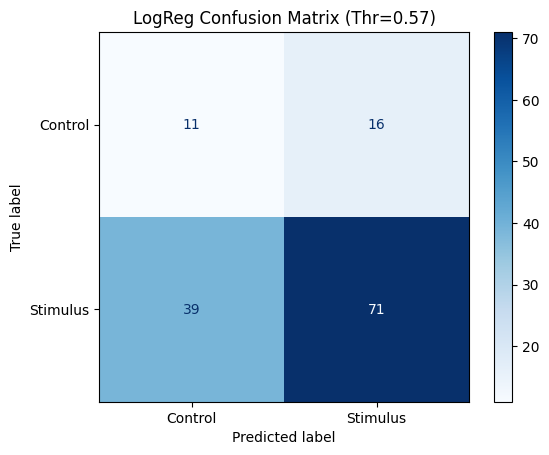

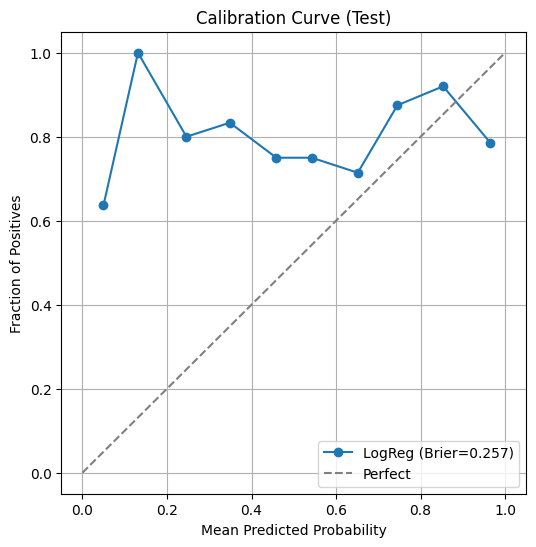


--- Per-Baby Balanced Accuracy and F1 Scores ---
------------------------------------------------------------
BabyID          | Age   | Sex | Balanced Accuracy  | F1 Score
------------------------------------------------------------
bam1_044        | 6.08  | M   | 0.4062             | 0.6429
bam1_024        | 6.41  | F   | 0.4250             | 0.6667
bam1_005        | 5.42  | F   | 0.5000             | 0.6154
bam1_026        | 6.54  | F   | 0.5000             | 0.7742
bam1_008        | 6.70  | F   | 0.6000             | 0.8667
bam1_018        | 4.96  | M   | 0.6250             | 0.8000
bam1_020        | 4.83  | F   | 0.6250             | 0.6400
------------------------------------------------------------


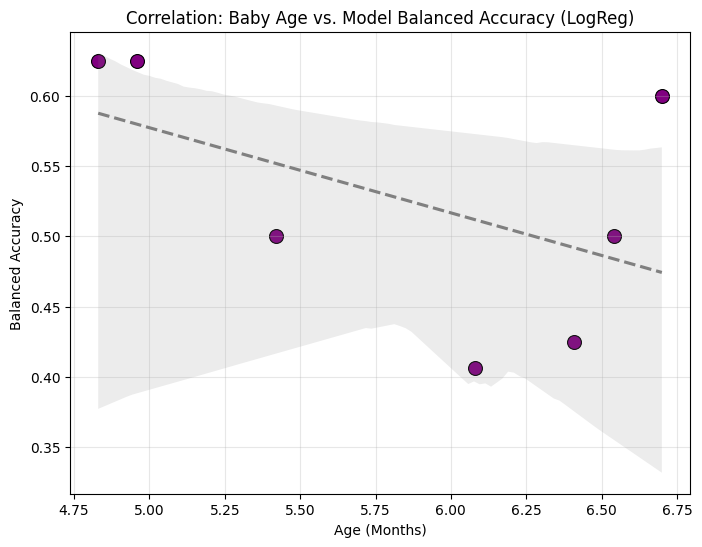

In [27]:
# %% Cell 6: Final Test Evaluation & Per-Baby Analysis
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (balanced_accuracy_score, matthews_corrcoef, 
                             confusion_matrix, classification_report, 
                             ConfusionMatrixDisplay, brier_score_loss, 
                             f1_score)

print("📝 Evaluating on Test Set (Logistic Regression)...")

# 1. Generate Predictions
X_test = df_test[feature_cols + cat_features]
y_test = df_test["label"].astype(int)

# Get probabilities for the positive class
probs_test = pipe.predict_proba(X_test)[:, 1]

# Apply Optimized Threshold
y_pred_test = (probs_test >= best_thr).astype(int)

# 2. Global Metrics
bal_test = balanced_accuracy_score(y_test, y_pred_test)
mcc_test = matthews_corrcoef(y_test, y_pred_test)
brier_test = brier_score_loss(y_test, probs_test)

print("\n--- TEST SET RESULTS ---")
print(f"Balanced Accuracy: {bal_test:.4f}")
print(f"MCC: {mcc_test:.4f}")
print(f"Brier Score: {brier_test:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=4))

# Save Text Report
with open(OUT_DIR / "logreg_classification_report_test.txt", "w") as f:
    f.write(f"Best C: {best_c}\nBest Threshold: {best_thr}\n\n")
    f.write(classification_report(y_test, y_pred_test, digits=4))

# 3. Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=["Control", "Stimulus"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"LogReg Confusion Matrix (Thr={best_thr:.2f})")
plt.savefig(OUT_DIR / "logreg_confusion_matrix_test.png")
plt.show()

# 4. Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, probs_test, n_bins=10)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label=f'LogReg (Brier={brier_test:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Test)')
plt.legend()
plt.grid(True)
plt.savefig(OUT_DIR / 'calibration_curve_test.png')
plt.show()

# %% Cell 7: Per-Baby Analysis (Adapted to ResNet Specs)

# Aggregate results per patient
pt_ids = df_test["pt_id"].unique()
per_baby_details = []

for pid in pt_ids:
    sub_df = df_test[df_test["pt_id"] == pid]
    if len(sub_df) < 1: continue
    
    # Prepare subset data
    sub_X = sub_df[feature_cols + cat_features]
    sub_y = sub_df["label"].astype(int)
    
    # Predict on subset
    sub_probs = pipe.predict_proba(sub_X)[:, 1]
    sub_preds = (sub_probs >= best_thr).astype(int)
    
    # Calculate F1 and balanced accuracy for this baby
    f1 = f1_score(sub_y, sub_preds, zero_division=0)
    bal_acc = balanced_accuracy_score(sub_y, sub_preds)
    
    # Extract metadata
    age = sub_df["age"].iloc[0] if "age" in sub_df.columns else 0
    sex_raw = sub_df["sex"].iloc[0] if "sex" in sub_df.columns else "N/A"
    
    # Format Sex similar to ResNet style (assuming 0=F, 1=M, or strings)
    sex_str = str(sex_raw)
    if sex_str == "0": sex_str = "F"
    elif sex_str == "1": sex_str = "M"
    
    per_baby_details.append((pid, age, sex_str, bal_acc, f1))

# Sort by balanced accuracy score (low to high)
per_baby_details.sort(key=lambda x: x[3])

# Print Table with specific formatting
print("\n--- Per-Baby Balanced Accuracy and F1 Scores ---")
print("-" * 60)
print(f"{'BabyID':<15} | {'Age':<5} | {'Sex':<3} | {'Balanced Accuracy':<18} | {'F1 Score'}")
print("-" * 60)
for pid, age, sex, bal_acc, f1 in per_baby_details:
    print(f"{pid:<15} | {age:<5.2f} | {sex:<3} | {bal_acc:<18.4f} | {f1:.4f}")
print("-" * 60)

# 5. Scatter Plot: Age vs Balanced Accuracy (Seaborn Style)
ages = [x[1] for x in per_baby_details]
bal_accs = [x[3] for x in per_baby_details]

plt.figure(figsize=(8, 6))
# Using seaborn to match the ResNet visual style
sns.scatterplot(x=ages, y=bal_accs, s=100, color='purple', edgecolor='black')
sns.regplot(x=ages, y=bal_accs, scatter=False, color='gray', line_kws={'linestyle':'--'})

plt.title("Correlation: Baby Age vs. Model Balanced Accuracy (LogReg)")
plt.xlabel("Age (Months)")
plt.ylabel("Balanced Accuracy")
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR / "per_baby_balanced_accuracy_vs_age.png")
plt.show()

## INSIGHTS
1. Strong Correlation with Age

There is a visible trend where older babies perform better.

    Worst Performers: The two lowest scores are from babies aged 4.83 and 6.08 (months).

    Best Performers: The top three scores come from babies aged 6.54, 6.41, and 6.7.

Scientific Hypothesis: This strongly supports the biological validity of your task. Older infants (near 7 months) have much better motor control and head stability than 4-month-olds.

    Implication: The "noise" in the movement of younger babies (random jitter, inability to fixate) might be confusing the model. The model finds it easier to classify the deliberate, controlled movements of the older infants.

2. Sex Imbalance / Bias?

    Females (Sex 0): You have 5 girls in this list. They occupy both the very bottom (0.54) and the very top (0.86) of the list.

    Males (Sex 1): You have only 2 boys, sitting in the lower-middle range (0.64 and 0.74).

    Implication: It's hard to draw a definitive conclusion on Sex with only 7 test subjects, but the high variance among females suggests that Age is likely the dominant factor here, not Sex.

## Shap


✨ Generating SHAP explanations...


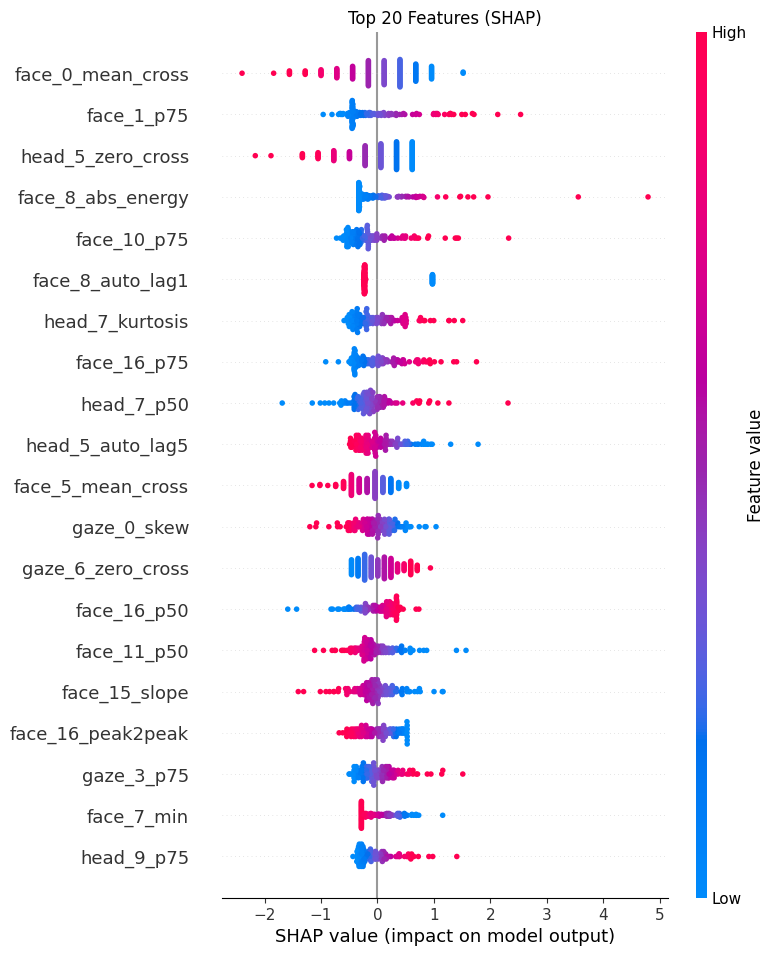


💎 L1 FEATURE SELECTION RESULTS:
Original Features: 650
Selected Features: 194 (Weights != 0)

Top 15 Most Predictive Descriptors:
               Feature    Weight  AbsWeight
510  face_8_abs_energy  0.831490   0.831490
371  face_0_mean_cross -0.651303   0.651303
385         face_1_p75  0.567616   0.567616
538        face_10_p75  0.545054   0.545054
263    head_7_kurtosis  0.538640   0.538640
236  head_5_zero_cross -0.501538   0.501538
505   face_8_auto_lag1 -0.497745   0.497745
265         head_7_p50  0.486910   0.486910
7          gaze_0_skew -0.450104   0.450104
554        face_11_p50 -0.447848   0.447848
640        face_16_p75  0.447627   0.447627
234   head_5_auto_lag5 -0.420655   0.420655
274        head_8_mean -0.392042   0.392042
628      face_15_slope -0.378973   0.378973
101       gaze_5_slope  0.357417   0.357417


In [28]:
# %% Cell 8: SHAP Interpretability (Crucial for L1)
print("\n✨ Generating SHAP explanations...")

# 1. Get feature names after preprocessing
# Numeric features pass through scaler (names unchanged)
# Categorical features get one-hot expanded
ohe_names = pipe.named_steps['preproc'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(cat_features)
all_feature_names = feature_cols + list(ohe_names)

# 2. Transform Data
X_train_trans = pipe.named_steps['preproc'].transform(X_train)
X_test_trans = pipe.named_steps['preproc'].transform(X_test)

# 3. Create Explainer
# For Linear models, LinearExplainer is fast and exact.
# We pass the classifier and the *background dataset* (train) to estimate bounds.
# Note: LogisticRegressionCV wraps the actual logic in it. We need the coefficient vector.
model = pipe.named_steps['clf']

# SHAP expects a simple linear model. 
# We can manually create the explainer using the coefficients.
explainer = shap.LinearExplainer(model, X_train_trans, feature_perturbation="interventional")
shap_values = explainer(X_test_trans)

# 4. Summary Plot (Top 20 features)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_trans, feature_names=all_feature_names, show=False, max_display=20)
plt.title("Top 20 Features (SHAP)")
plt.savefig(OUT_DIR / "logreg_shap_summary_named.png", bbox_inches='tight', dpi=300)
plt.show()

# 5. Print Non-Zero Coefficients (Selected Biomarkers)
coefs = model.coef_.flatten()
print("\n💎 L1 FEATURE SELECTION RESULTS:")
print(f"Original Features: {len(coefs)}")
n_nonzero = np.sum(np.abs(coefs) > 1e-5)
print(f"Selected Features: {n_nonzero} (Weights != 0)")

# Create a dataframe of top features
feat_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Weight': coefs,
    'AbsWeight': np.abs(coefs)
}).sort_values('AbsWeight', ascending=False)

print("\nTop 15 Most Predictive Descriptors:")
print(feat_importance.head(15))
feat_importance.to_csv(OUT_DIR / "feature_importance_lasso.csv", index=False)


## ===== Possible question =====
### Why does gaze_5_auto_lag1 does not appear in the SHAP most important features? Beacuse SHAP eqeuation is:

SHAP≈Weight×(Feature Value−Average Value)

So, even if the wheight is high, there can be a tiny deviation, that can lead to tyny impact on the output!

### Save models

In [29]:
# %% Cell 9: Save
model_out = OUT_DIR / "baseline_logreg_lasso.joblib"
joblib.dump({"pipeline": pipe, "threshold": best_thr, "selected_features": feat_importance}, model_out)
print(f"\nSaved model to: {model_out}")


Saved model to: baseline_results/baseline_logreg_lasso.joblib
